# KardioSense vs ISIBrno — Step 3: Lead Ablation

**Question:** How does each model degrade as fewer leads are available?

KardioSense is designed to work from 1 lead (thumb pads only) up to 6 leads 
(full cable). ISIBrno was designed for 2–12 leads. This step forces ISIBrno 
into KardioSense's lead configs and measures the performance gap at each level.

**Configurations tested (both models):**

| Config | Leads | Device context |
|---|---|---|
| 1-lead | I | Thumb pads only — mass screening |
| 2-lead | I, II | + single chest electrode |
| 3-lead | I, II, aVF | Inferior MI coverage added |
| 6-lead | I, II, III, aVF, V2, V4 | Full KardioSense cable |
| 12-lead | All | ISIBrno native (reference ceiling) |

**Inputs required:** NB02 checkpoint, Step 1 ISIBrno checkpoint, PTB-XL cache, 
`benchmark/threshold_config.json` from Step 2 Section 9b.


**Baseline citation:** ISIBrno-AIMT (Nejedly et al., 2021); PhysioNet/CinC Challenge 2021 (Reyna et al., 2021) — see `REFERENCES.md`.

## 0. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE_DIR = os.environ.get('KARDIOSENSE_BASE_DIR', '/content/drive/MyDrive/KardioSenseAI')
DATA_DIR = f'{BASE_DIR}/datasets'
PTBXL_DIR = f'{DATA_DIR}/ptb-xl'
CKPT_DIR = f'{BASE_DIR}/checkpoints'
LOG_DIR = f'{BASE_DIR}/logs'
BENCH_DIR = f'{BASE_DIR}/benchmark'

required = {
    'PTB-XL cache' : f'{DATA_DIR}/ptbxl_preprocessed_500hz.npz',
    'KardioSense checkpoint': f'{CKPT_DIR}/kardiosense_ecg_best_mi.pt',
    'ISIBrno checkpoint' : f'{CKPT_DIR}/isibrno_ptbxl_best_mi.pt',
    'Threshold config' : f'{BENCH_DIR}/threshold_config.json',
    'Ground truth labels' : f'{BENCH_DIR}/labels_test_fold10.npy',
}
print('Checking inputs:')
all_ok = True
for name, path in required.items():
    ok = os.path.exists(path)
    size = f'{os.path.getsize(path)/1e6:.1f} MB' if ok else '—'
    print(f' {"" if ok else ""} {name:<28} {size}')
    if not ok: all_ok = False
assert all_ok, 'Missing files — run Step 1 and Step 2 (incl. Section 9b) first.'
print('\n All inputs present.')


Mounted at /content/drive
Checking inputs:
  ✅ PTB-XL cache                  932.9 MB
  ✅ KardioSense checkpoint        36.5 MB
  ✅ ISIBrno checkpoint            26.2 MB
  ✅ Threshold config              0.0 MB
  ✅ Ground truth labels           0.0 MB

✅ All inputs present.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
import json, time, warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
LABEL_NAMES = ['NORM', 'MI', 'AFIB', 'STTC', 'CD']
ALL_LEADS = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']

# Lead indices within the PTB-XL 12-lead array
LEAD_IDX = {name: i for i, name in enumerate(ALL_LEADS)}

# KardioSense 6-lead subset (indices into the 12-lead array)
SIX_LEAD_INDICES = [0, 1, 2, 5, 7, 9] # I, II, III, aVF, V2, V4
SIX_LEAD_NAMES = [ALL_LEADS[i] for i in SIX_LEAD_INDICES]

# ── Load threshold config from Step 2 Section 9b ─────────────────────────
with open(f'{BENCH_DIR}/threshold_config.json') as f:
    thr_cfg = json.load(f)

KS_MI_THR = thr_cfg['mi_threshold_ks']
IB_MI_THR = thr_cfg['mi_threshold_ib']
print(f'Thresholds (from Step 2):')
print(f' KardioSense MI : {KS_MI_THR:.2f}')
print(f' ISIBrno MI : {IB_MI_THR:.2f}')
print(f' All other classes: 0.50 (default — Step 2 showed no benefit from tuning NORM/STTC/CD)')
print(f'Device: {DEVICE}')


Thresholds (from Step 2):
  KardioSense MI : 0.93
  ISIBrno     MI : 0.74
  All other classes: 0.50 (default — Step 2 showed no benefit from tuning NORM/STTC/CD)
Device: cuda


## 1. Load Cache & Reproduce Test Split

In [3]:
print('Loading cache...')
cache = np.load(f'{DATA_DIR}/ptbxl_preprocessed_500hz.npz')
X = cache['X'] # (N, 5000, 12)
Y = cache['Y'] # (N, 5)
ecg_ids = cache['ecg_ids']

df_meta = pd.read_csv(f'{PTBXL_DIR}/ptbxl_database.csv', index_col='ecg_id')
df_filtered = df_meta.loc[ecg_ids]
test_idx = np.where(df_filtered['strat_fold'] == 10)[0]
X_test = X[test_idx]
Y_test = Y[test_idx]

# Verify against saved ground truth
labels_ref = np.load(f'{BENCH_DIR}/labels_test_fold10.npy')
assert np.allclose(labels_ref, Y_test), ' Label mismatch'

print(f' Test set: {len(X_test):,} records × 12 leads × 5000 samples')
print(f' Class counts: ' + ' '.join(f'{l}={int(Y_test[:,i].sum())}' for i,l in enumerate(LABEL_NAMES)))


Loading cache...
✅ Test set: 499 records × 12 leads × 5000 samples
   Class counts: NORM=229  MI=64  AFIB=2  STTC=134  CD=118


## 2. Load Both Model Architectures

Both models are loaded from their Step 1 / NB02 checkpoints — no retraining. 
We only change which leads are passed in at inference time.


In [4]:
# ── KardioSense ─────────────────────────────────────────────────────────────
class ResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=7, stride=1, dropout=0.2):
        super().__init__()
        pad = kernel_size // 2
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, stride=stride, padding=pad, bias=False)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, stride=1, padding=pad, bias=False)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.drop = nn.Dropout(dropout)
        self.skip = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, 1, stride=stride, bias=False), nn.BatchNorm1d(out_ch)
        ) if (in_ch != out_ch or stride != 1) else nn.Identity()
    def forward(self, x):
        r = self.skip(x)
        o = F.relu(self.bn1(self.conv1(x)))
        o = self.drop(o)
        return F.relu(self.bn2(self.conv2(o)) + r)

class AttentionPool(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.a = nn.Linear(d, 1)
    def forward(self, x):
        w = torch.softmax(self.a(x), dim=1)
        return (x * w).sum(dim=1), w.squeeze(-1)

class KardioSenseECGModel(nn.Module):
    def __init__(self, n_leads=6, n_classes=5, dropout=0.3):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(n_leads, 32, 15, stride=2, padding=7, bias=False),
            nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(3, stride=2, padding=1))
        self.layer1 = ResBlock1D(32, 64, stride=2, dropout=dropout)
        self.layer2 = ResBlock1D(64, 128, stride=2, dropout=dropout)
        self.layer3 = ResBlock1D(128, 256, stride=2, dropout=dropout)
        self.layer4 = ResBlock1D(256, 256, stride=2, dropout=dropout)
        self.bilstm = nn.LSTM(256, 128, num_layers=2, batch_first=True,
                              bidirectional=True, dropout=dropout)
        self.self_attn = nn.MultiheadAttention(256, 4, dropout=dropout, batch_first=True)
        self.attn_norm = nn.LayerNorm(256)
        self.attn_pool = AttentionPool(256)
        self.mask_proj = nn.Sequential(nn.Linear(n_leads, 32), nn.ReLU())
        self.classifier = nn.Sequential(
            nn.Linear(288, 128), nn.ReLU(), nn.Dropout(dropout), nn.Linear(128, n_classes))
    def forward(self, sig, mask):
        x = self.layer4(self.layer3(self.layer2(self.layer1(self.stem(sig)))))
        x = x.permute(0, 2, 1)
        x, _ = self.bilstm(x)
        ao, _ = self.self_attn(x, x, x)
        x = self.attn_norm(x + ao)
        e, _ = self.attn_pool(x)
        return self.classifier(torch.cat([e, self.mask_proj(mask)], dim=-1)), None

ckpt_ks = torch.load(f'{CKPT_DIR}/kardiosense_ecg_best_mi.pt', map_location=DEVICE, weights_only=True)
model_ks = KardioSenseECGModel(n_leads=6, n_classes=5, dropout=0.3).to(DEVICE)
model_ks.load_state_dict(ckpt_ks['model_state'])
model_ks.eval()
print(f' KardioSense: epoch={ckpt_ks["epoch"]} val MI AUC={ckpt_ks["mi_auc"]:.4f}')


✅ KardioSense: epoch=40  val MI AUC=0.9191


In [5]:
# ── ISIBrno ─────────────────────────────────────────────────────────────────
class ISIBrnoResidualBlock(nn.Module):
    def __init__(self, downsample):
        super().__init__()
        self.downsample = downsample
        self.stride = 2 if downsample else 1
        K, P = 9, 4
        self.conv1 = nn.Conv2d(256,256,(1,K),stride=(1,self.stride),padding=(0,P),bias=False)
        self.bn1 = nn.BatchNorm2d(256)
        self.conv2 = nn.Conv2d(256,256,(1,K),padding=(0,P),bias=False)
        self.bn2 = nn.BatchNorm2d(256)
        if downsample:
            self.idfunc_0 = nn.AvgPool2d(kernel_size=(1,2),stride=(1,2))
            self.idfunc_1 = nn.Conv2d(256,256,(1,1),bias=False)
    def forward(self, x):
        identity = x
        x = F.leaky_relu(self.bn1(self.conv1(x)))
        x = F.leaky_relu(self.bn2(self.conv2(x)))
        if self.downsample:
            identity = self.idfunc_1(self.idfunc_0(identity))
        return x + identity

class ISIBrnoNN(nn.Module):
    def __init__(self, nOUT=5):
        super().__init__()
        self.conv = nn.Conv2d(12,256,(1,15),padding=(0,7),stride=(1,2),bias=False)
        self.bn = nn.BatchNorm2d(256)
        self.rb_0 = ISIBrnoResidualBlock(downsample=True)
        self.rb_1 = ISIBrnoResidualBlock(downsample=True)
        self.rb_2 = ISIBrnoResidualBlock(downsample=True)
        self.rb_3 = ISIBrnoResidualBlock(downsample=True)
        self.rb_4 = ISIBrnoResidualBlock(downsample=True)
        self.mha = nn.MultiheadAttention(256, 8)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc_1 = nn.Linear(256+12, nOUT)
        self.ch_fc1 = nn.Linear(nOUT,256)
        self.ch_bn = nn.BatchNorm1d(256)
        self.ch_fc2 = nn.Linear(256,nOUT)
    def forward(self, x, l):
        x = F.leaky_relu(self.bn(self.conv(x)))
        x = self.rb_4(self.rb_3(self.rb_2(self.rb_1(self.rb_0(x)))))
        x = F.dropout(x, p=0.5, training=self.training)
        x = x.squeeze(2).permute(2,0,1)
        x, _ = self.mha(x,x,x)
        x = x.permute(1,2,0)
        x = self.pool(x).squeeze(2)
        x = torch.cat((x,l),dim=1)
        x = self.fc_1(x)
        p = x.detach()
        p = F.leaky_relu(self.ch_bn(self.ch_fc1(p)))
        p = torch.sigmoid(self.ch_fc2(p))
        return x, p

ckpt_ib = torch.load(f'{CKPT_DIR}/isibrno_ptbxl_best_mi.pt', map_location=DEVICE, weights_only=True)
model_ib = ISIBrnoNN(nOUT=5).to(DEVICE)
model_ib.load_state_dict(ckpt_ib['model_state'])
model_ib.eval()
print(f' ISIBrno: epoch={ckpt_ib["epoch"]} val MI AUC={ckpt_ib["mi_auc"]:.4f}')

ks_params = sum(p.numel() for p in model_ks.parameters())
ib_params = sum(p.numel() for p in model_ib.parameters())
print(f'\nParam counts: KardioSense={ks_params:,} ISIBrno={ib_params:,}')


✅ ISIBrno:     epoch=45  val MI AUC=0.9127

Param counts:  KardioSense=3,028,710  ISIBrno=6,545,478


## 3. Lead Configurations

Five configurations per model. KardioSense always uses its 6-lead input tensor 
(zeroing out absent leads via the mask — exactly as in training). ISIBrno uses 
its 12-lead input tensor with absent leads zeroed and the lead-indicator vector 
set accordingly.


In [6]:
# ── Lead configurations to sweep ──────────────────────────────────────────
# Each config specifies which PTB-XL lead indices are "active"
# KardioSense maps these into its 6-lead slot indices
# ISIBrno uses them directly in the 12-lead tensor + indicator vector

ABLATION_CONFIGS = [
    {
        'name' : '1-lead (I)',
        'short' : '1L',
        'ptbxl_idx' : [0], # Lead I only
        'ks_slots' : [0], # slot 0 in the 6-lead tensor
        'device_ctx' : 'Thumb pads only',
    },
    {
        'name' : '2-lead (I, II)',
        'short' : '2L',
        'ptbxl_idx' : [0, 1],
        'ks_slots' : [0, 1],
        'device_ctx' : '+ single chest electrode',
    },
    {
        'name' : '3-lead (I, II, aVF)',
        'short' : '3L',
        'ptbxl_idx' : [0, 1, 5],
        'ks_slots' : [0, 1, 3], # aVF is slot 3 in [I,II,III,aVF,V2,V4]
        'device_ctx' : 'Inferior MI coverage',
    },
    {
        'name' : '6-lead (full KS cable)',
        'short' : '6L',
        'ptbxl_idx' : [0, 1, 2, 5, 7, 9], # I,II,III,aVF,V2,V4
        'ks_slots' : [0, 1, 2, 3, 4, 5],
        'device_ctx' : 'Full KardioSense cable',
    },
    {
        'name' : '12-lead (ISIBrno native)',
        'short' : '12L',
        'ptbxl_idx' : list(range(12)),
        'ks_slots' : None, # KS cannot use 12-lead (trained on 6)
        'device_ctx' : 'Hospital 12-lead (IB reference ceiling)',
    },
]

for cfg in ABLATION_CONFIGS:
    leads = [ALL_LEADS[i] for i in cfg['ptbxl_idx']]
    print(f' {cfg["short"]:3s} {cfg["name"]:<30s} Leads: {leads}')


  1L   1-lead (I)                      Leads: ['I']
  2L   2-lead (I, II)                  Leads: ['I', 'II']
  3L   3-lead (I, II, aVF)             Leads: ['I', 'II', 'aVF']
  6L   6-lead (full KS cable)          Leads: ['I', 'II', 'III', 'aVF', 'V2', 'V4']
  12L  12-lead (ISIBrno native)        Leads: ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


## 4. Lead-Controlled Inference Functions

In [9]:
ISIBRNO_WINDOW = 8192

def infer_ks(model, X_np, Y_np, ks_slots, batch_size=128, device=DEVICE):
    """
    Run KardioSense inference with only the specified slot indices active.
    ks_slots: list of indices into the 6-lead tensor that are 'on'.
    All 6 slots are always passed; inactive slots are zeroed + mask=0.
    """
    model.eval()
    all_preds, all_labels = [], []
    n_leads = 6

    # Build fixed mask
    fixed_mask = torch.zeros(n_leads, dtype=torch.float32)
    for s in ks_slots:
        fixed_mask[s] = 1.0

    for i in range(0, len(X_np), batch_size):
        xb = X_np[i:i+batch_size] # (B, 5000, 12)
        yb = Y_np[i:i+batch_size]
        # Extract the 6 KS leads from the 12-lead array
        sig = xb[:, :, SIX_LEAD_INDICES].transpose(0, 2, 1).astype(np.float32) # (B,6,5000)
        sig = torch.tensor(sig, dtype=torch.float32).to(device)
        # Zero inactive leads
        sig = sig * fixed_mask.to(device).view(1, n_leads, 1)
        msk = fixed_mask.unsqueeze(0).expand(len(xb), -1).to(device)
        with torch.no_grad():
            logits, _ = model(sig, msk)
            preds = torch.sigmoid(logits).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(yb)

    return np.vstack(all_preds), np.vstack(all_labels)


def infer_ib(model, X_np, Y_np, ptbxl_idx, batch_size=64, device=DEVICE):
    """
    Run ISIBrno inference with only the specified PTB-XL lead indices active.
    Absent leads are zeroed in the 12-lead tensor; lead indicator = 0.
    Window is padded to 8192 samples as in Step 1.
    """
    model.eval()
    all_preds, all_labels = [], []

    # Build fixed 12-dim lead indicator
    lead_indicator = torch.zeros(12, dtype=torch.float32)
    for idx in ptbxl_idx:
        lead_indicator[idx] = 1.0

    for i in range(0, len(X_np), batch_size):
        xb = X_np[i:i+batch_size] # (B, 5000, 12)
        yb = Y_np[i:i+batch_size]
        B = len(xb)

        sig = xb.transpose(0, 2, 1).astype(np.float32) # (B, 12, 5000)
        # Zero inactive leads
        mask_np = lead_indicator.numpy()
        sig = sig * mask_np[np.newaxis, :, np.newaxis]

        # Pad to ISIBrno window
        if sig.shape[2] < ISIBRNO_WINDOW:
            pad = np.zeros((B, 12, ISIBRNO_WINDOW - sig.shape[2]), dtype=np.float32)
            sig = np.concatenate([sig, pad], axis=2)

        x_t = torch.tensor(sig, dtype=torch.float32).unsqueeze(2).to(device) # (B,12,1,8192)
        l_t = lead_indicator.unsqueeze(0).expand(B, -1).to(device)

        with torch.no_grad():
            logits, _ = model(x_t, l_t)
            preds = torch.sigmoid(logits).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(yb)

    return np.vstack(all_preds), np.vstack(all_labels)


def compute_metrics(y_true, y_score, thr_ks_mi, thr_ib_mi, model_tag):
    """Compute AUC, AP, recall, precision, F1 for all classes."""
    thr_map = {
        'ks': {'NORM':0.5,'MI':thr_ks_mi,'AFIB':0.5,'STTC':0.5,'CD':0.5},
        'ib': {'NORM':0.5,'MI':thr_ib_mi,'AFIB':0.5,'STTC':0.5,'CD':0.5},
    }[model_tag]

    results = {}
    for i, lbl in enumerate(LABEL_NAMES):
        yt = y_true[:, i]
        yp = y_score[:, i]
        if yt.sum() == 0:
            results[lbl] = {'auc': np.nan, 'ap': np.nan, 'recall': np.nan,
                            'precision': np.nan, 'f1': np.nan}
            continue
        thr = thr_map[lbl]
        yb = (yp >= thr).astype(int)
        tp = int((yb * yt).sum())
        fp = int((yb * (1-yt)).sum())
        fn = int(((1-yb) * yt).sum())
        rec = tp / (tp + fn + 1e-8)
        prec = tp / (tp + fp + 1e-8)
        f1 = 2*prec*rec / (prec + rec + 1e-8)
        results[lbl] = {
            'auc': roc_auc_score(yt, yp),
            'ap' : average_precision_score(yt, yp),
            'recall': rec, 'precision': prec, 'f1': f1,
            'tp': tp, 'fp': fp, 'fn': fn,
        }
    macro_auc = float(np.nanmean([results[l]['auc'] for l in LABEL_NAMES]))
    macro_f1 = float(np.nanmean([results[l]['f1'] for l in LABEL_NAMES]))
    results['MACRO'] = {'auc': macro_auc, 'f1': macro_f1}
    return results

print(' Inference functions defined.')


✅ Inference functions defined.


## 5. Run Lead Ablation

Runs all 5 configurations for both models. KardioSense skips 12-lead 
(it was trained on 6 leads — running it with a zeroed 12-lead config 
is undefined; the 12-lead row is ISIBrno's reference ceiling only).


In [10]:
ablation_results = {} # {config_short: {'ks': metrics, 'ib': metrics}}

print('Running lead ablation sweep...')
print('─' * 65)

for cfg in ABLATION_CONFIGS:
    short = cfg['short']
    name = cfg['name']
    ptbxl_idx = cfg['ptbxl_idx']
    ks_slots = cfg['ks_slots']

    row = {}
    t0 = time.time()

    # ── KardioSense ──────────────────────────────────────────────────────
    if ks_slots is not None:
        preds_ks, labels_ks = infer_ks(model_ks, X_test, Y_test, ks_slots)
        row['ks'] = compute_metrics(labels_ks, preds_ks, KS_MI_THR, IB_MI_THR, 'ks')
        mi_ks_auc = row['ks']['MI']['auc']
        mi_ks_rec = row['ks']['MI']['recall']
    else:
        row['ks'] = None
        mi_ks_auc = float('nan')
        mi_ks_rec = float('nan')

    # ── ISIBrno ──────────────────────────────────────────────────────────
    preds_ib, labels_ib = infer_ib(model_ib, X_test, Y_test, ptbxl_idx)
    row['ib'] = compute_metrics(labels_ib, preds_ib, KS_MI_THR, IB_MI_THR, 'ib')
    mi_ib_auc = row['ib']['MI']['auc']
    mi_ib_rec = row['ib']['MI']['recall']

    ablation_results[short] = row
    elapsed = time.time() - t0

    ks_str = f'KS MI AUC={mi_ks_auc:.3f} Rec={mi_ks_rec:.2f}' if row['ks'] else 'KS: N/A (12-lead)'
    print(f' [{short:3s}] {name:<32s} {ks_str} | IB MI AUC={mi_ib_auc:.3f} Rec={mi_ib_rec:.2f} [{elapsed:.1f}s]')

print('─' * 65)
print(' Ablation complete.')


Running lead ablation sweep...
─────────────────────────────────────────────────────────────────
  [1L ] 1-lead (I)                        KS MI AUC=0.810 Rec=0.44  |  IB MI AUC=0.327 Rec=1.00  [2.5s]
  [2L ] 2-lead (I, II)                    KS MI AUC=0.844 Rec=0.73  |  IB MI AUC=0.716 Rec=0.97  [1.4s]
  [3L ] 3-lead (I, II, aVF)               KS MI AUC=0.831 Rec=0.73  |  IB MI AUC=0.724 Rec=1.00  [1.4s]
  [6L ] 6-lead (full KS cable)            KS MI AUC=0.915 Rec=0.77  |  IB MI AUC=0.848 Rec=0.62  [1.4s]
  [12L] 12-lead (ISIBrno native)          KS: N/A (12-lead)  |  IB MI AUC=0.935 Rec=0.77  [1.2s]
─────────────────────────────────────────────────────────────────
✅ Ablation complete.


## 6. Lead Ablation Results Tables

In [11]:
METRICS_SHOW = ['auc', 'recall', 'f1']
METRIC_LABEL = {'auc': 'AUC', 'recall': 'Recall', 'f1': 'F1'}
CONFIG_ORDER = ['1L', '2L', '3L', '6L', '12L']

for cls in ['MI', 'NORM', 'STTC', 'CD', 'MACRO']:
    print(f'\n{cls}')
    print(f' {"Config":<22}' + ''.join(f' {METRIC_LABEL[m]:>8}' for m in METRICS_SHOW) * 2)
    print(f' {"":22s}' + ' KardioSense ──────────' + ' ISIBrno ──────────────')
    print(' ' + '─' * 72)

    for short in CONFIG_ORDER:
        cfg = next(c for c in ABLATION_CONFIGS if c['short'] == short)
        row = ablation_results[short]
        name = cfg['name']

        ks_vals, ib_vals = [], []
        for m in METRICS_SHOW:
            if row['ks'] and cls in row['ks']:
                v = row['ks'][cls].get(m, float('nan'))
                ks_vals.append(f'{v:>8.3f}' if not np.isnan(v) else ' —')
            else:
                ks_vals.append(' —')
            if cls in row['ib']:
                v = row['ib'][cls].get(m, float('nan'))
                ib_vals.append(f'{v:>8.3f}' if not np.isnan(v) else ' —')
            else:
                ib_vals.append(' —')

        print(f' {name:<22}' + ''.join(ks_vals) + ' ' + ''.join(ib_vals))



MI
  Config                       AUC    Recall        F1       AUC    Recall        F1
                          KardioSense ──────────  ISIBrno ──────────────
  ────────────────────────────────────────────────────────────────────────
  1-lead (I)               0.810   0.437   0.389     0.327   1.000   0.227
  2-lead (I, II)           0.844   0.734   0.461     0.716   0.969   0.239
  3-lead (I, II, aVF)      0.831   0.734   0.461     0.724   1.000   0.227
  6-lead (full KS cable)   0.915   0.766   0.628     0.848   0.625   0.457
  12-lead (ISIBrno native)       —       —       —     0.935   0.766   0.612

NORM
  Config                       AUC    Recall        F1       AUC    Recall        F1
                          KardioSense ──────────  ISIBrno ──────────────
  ────────────────────────────────────────────────────────────────────────
  1-lead (I)               0.890   0.856   0.810     0.714   0.000   0.000
  2-lead (I, II)           0.905   0.838   0.815     0.849   0.131   0.2

## 7. Ablation Plots

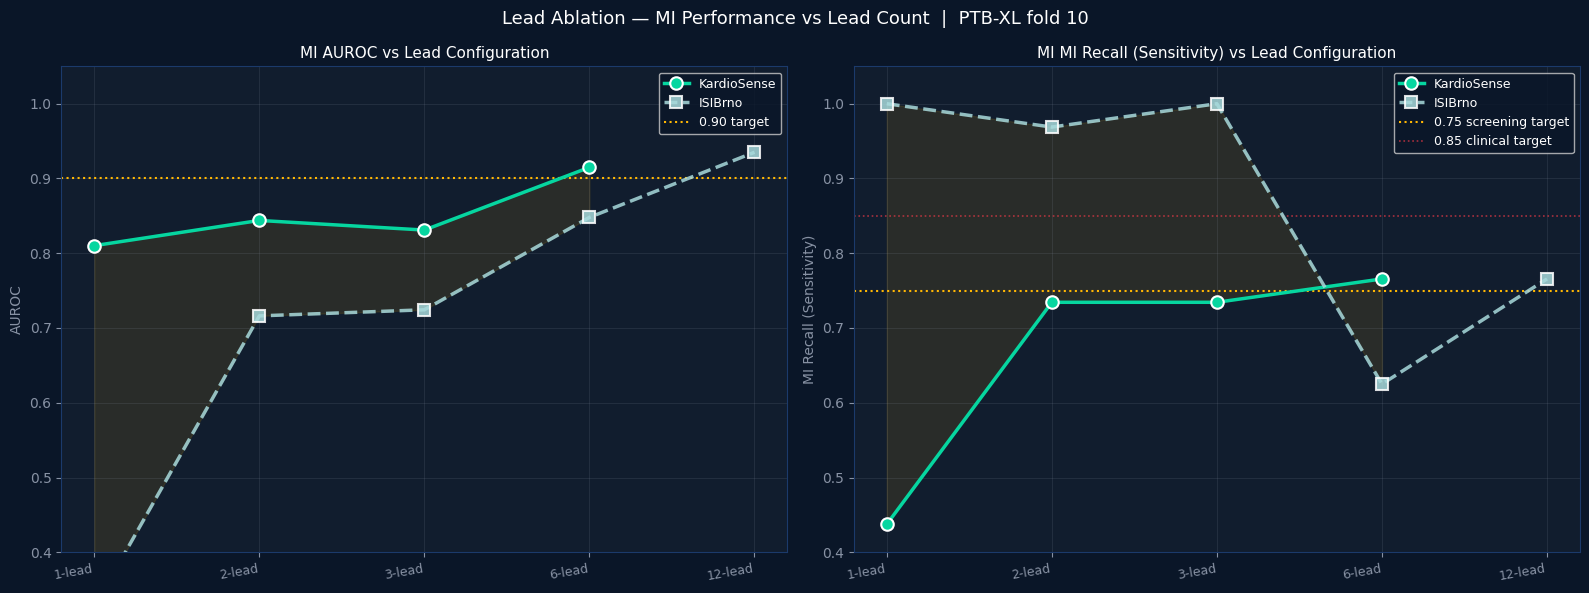

✅ Saved → /content/drive/MyDrive/KardioSenseAI/logs/ablation_mi_vs_leads.png


In [12]:
# ── Plot 1: MI AUC and Recall vs Lead Count ───────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='#0A1628')
fig.suptitle('Lead Ablation — MI Performance vs Lead Count | PTB-XL fold 10',
             color='white', fontsize=13)

config_labels = [cfg['name'].split('(')[0].strip() for cfg in ABLATION_CONFIGS]
x_all = np.arange(len(ABLATION_CONFIGS))

for ax in axes:
    ax.set_facecolor('#111D2E')
    for s in ax.spines.values(): s.set_edgecolor('#1B3A6B')
    ax.tick_params(colors='#8892A4')
    ax.grid(True, alpha=0.15, color='#8892A4')

for ax, metric, ylabel in [
    (axes[0], 'auc', 'AUROC'),
    (axes[1], 'recall', 'MI Recall (Sensitivity)'),
]:
    ks_vals, ib_vals = [], []
    ks_x, ib_x = [], []

    for i, (short, cfg) in enumerate(zip(CONFIG_ORDER, ABLATION_CONFIGS)):
        row = ablation_results[short]
        if row['ks']:
            v = row['ks']['MI'].get(metric, np.nan)
            if not np.isnan(v):
                ks_vals.append(v); ks_x.append(i)
        v = row['ib']['MI'].get(metric, np.nan)
        if not np.isnan(v):
            ib_vals.append(v); ib_x.append(i)

    ax.plot(ks_x, ks_vals, 'o-', color='#06D6A0', linewidth=2.5,
            markersize=9, markeredgewidth=1.5, markeredgecolor='white',
            label='KardioSense', zorder=4)
    ax.plot(ib_x, ib_vals, 's--', color='#A8DADC', linewidth=2.5,
            markersize=9, markeredgewidth=1.5, markeredgecolor='white',
            label='ISIBrno', zorder=4, alpha=0.85)

    # Shade the region between curves
    common_x = sorted(set(ks_x) & set(ib_x))
    ks_map = dict(zip(ks_x, ks_vals))
    ib_map = dict(zip(ib_x, ib_vals))
    cx = common_x
    kv = [ks_map[x] for x in cx]
    iv = [ib_map[x] for x in cx]
    ax.fill_between(cx, kv, iv, alpha=0.1, color='#FFB703')

    # Target line for MI AUC
    if metric == 'auc':
        ax.axhline(0.90, color='#FFB703', lw=1.5, linestyle=':', label='0.90 target')
    if metric == 'recall':
        ax.axhline(0.75, color='#FFB703', lw=1.5, linestyle=':', label='0.75 screening target')
        ax.axhline(0.85, color='#E63946', lw=1.2, linestyle=':', label='0.85 clinical target', alpha=0.7)

    ax.set_xticks(range(len(ABLATION_CONFIGS)))
    ax.set_xticklabels(config_labels, color='#8892A4', fontsize=9, rotation=10, ha='right')
    ax.set_ylabel(ylabel, color='#8892A4')
    ax.set_title(f'MI {ylabel} vs Lead Configuration', color='white', fontsize=11)
    ax.legend(facecolor='#0A1628', labelcolor='white', fontsize=9)
    ax.set_ylim(0.4, 1.05)

plt.tight_layout()
plt.savefig(f'{LOG_DIR}/ablation_mi_vs_leads.png', dpi=130,
            bbox_inches='tight', facecolor='#0A1628')
plt.show()
print(f' Saved → {LOG_DIR}/ablation_mi_vs_leads.png')


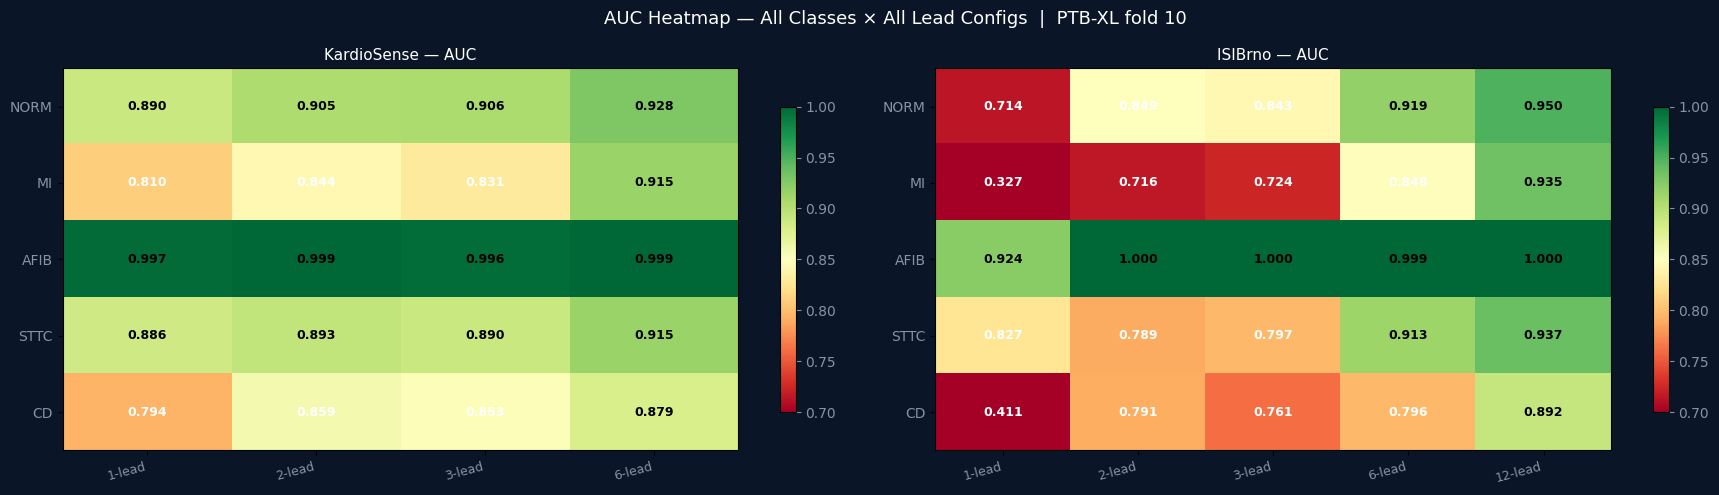

✅ Saved → /content/drive/MyDrive/KardioSenseAI/logs/ablation_auc_heatmap.png


In [13]:
# ── Plot 2: Full class AUC heatmap — both models across all configs ────────

fig, axes = plt.subplots(1, 2, figsize=(18, 5), facecolor='#0A1628')
fig.suptitle('AUC Heatmap — All Classes × All Lead Configs | PTB-XL fold 10',
             color='white', fontsize=13)

import matplotlib.colors as mcolors

cmap = plt.cm.RdYlGn

for ax, model_tag, title in [
    (axes[0], 'ks', 'KardioSense'),
    (axes[1], 'ib', 'ISIBrno'),
]:
    ax.set_facecolor('#111D2E')

    classes = LABEL_NAMES
    configs_present = [s for s in CONFIG_ORDER
                       if ablation_results[s].get(model_tag) is not None]
    cfg_labels_present = [next(c['name'] for c in ABLATION_CONFIGS if c['short']==s)
                          .split('(')[0].strip() for s in configs_present]

    mat = np.full((len(classes), len(configs_present)), np.nan)
    for j, short in enumerate(configs_present):
        row = ablation_results[short][model_tag]
        for i, cls in enumerate(classes):
            if cls in row:
                mat[i, j] = row[cls].get('auc', np.nan)

    im = ax.imshow(mat, cmap=cmap, vmin=0.70, vmax=1.0, aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.8).ax.tick_params(colors='#8892A4')

    for i in range(len(classes)):
        for j in range(len(configs_present)):
            v = mat[i, j]
            if not np.isnan(v):
                color = 'black' if v > 0.87 else 'white'
                ax.text(j, i, f'{v:.3f}', ha='center', va='center',
                        fontsize=9, color=color, fontweight='bold')

    ax.set_xticks(range(len(configs_present)))
    ax.set_xticklabels(cfg_labels_present, color='#8892A4', fontsize=9, rotation=15, ha='right')
    ax.set_yticks(range(len(classes)))
    ax.set_yticklabels(classes, color='#8892A4', fontsize=10)
    ax.set_title(f'{title} — AUC', color='white', fontsize=11)

plt.tight_layout()
plt.savefig(f'{LOG_DIR}/ablation_auc_heatmap.png', dpi=130,
            bbox_inches='tight', facecolor='#0A1628')
plt.show()
print(f' Saved → {LOG_DIR}/ablation_auc_heatmap.png')


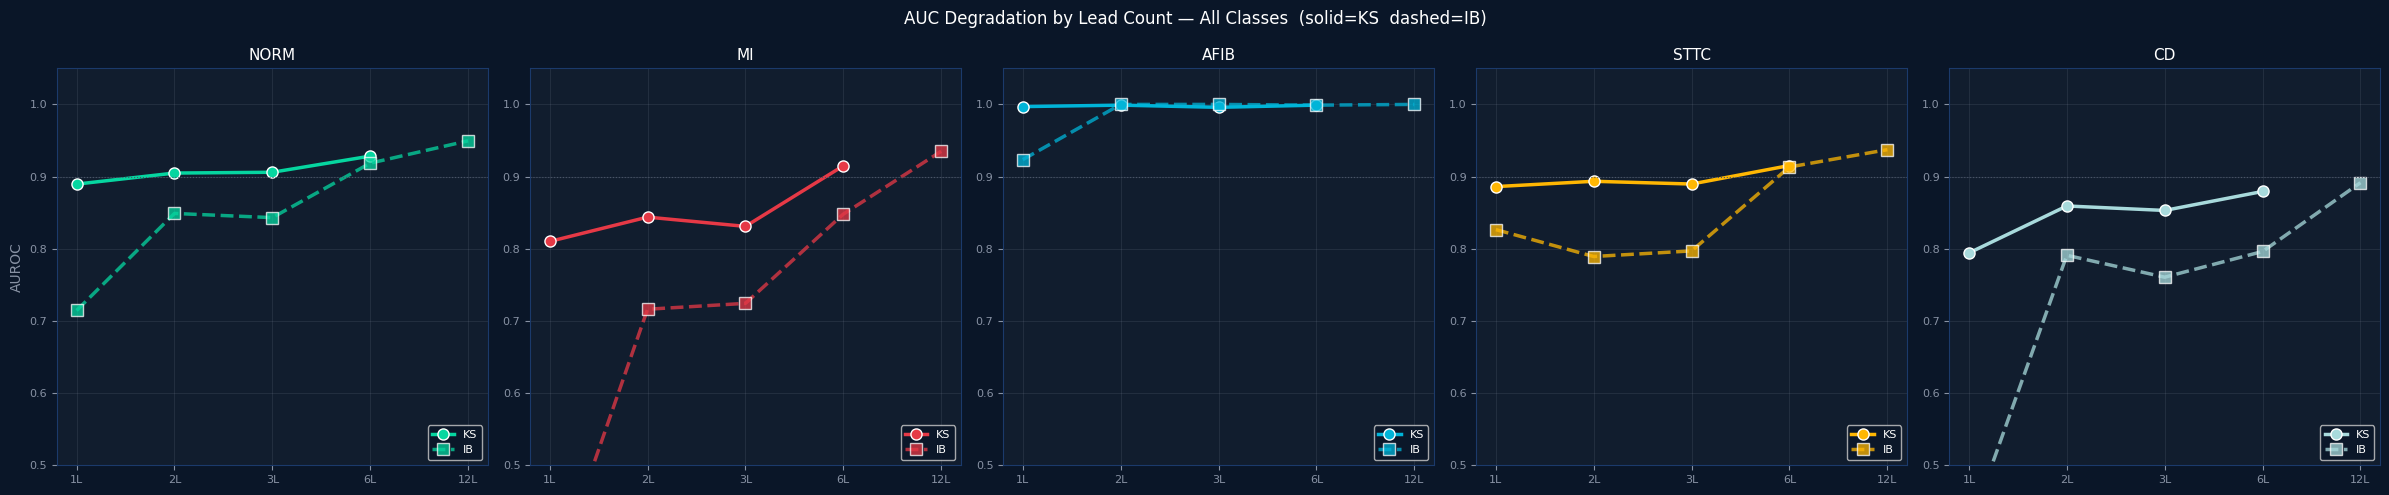

✅ Saved → /content/drive/MyDrive/KardioSenseAI/logs/ablation_degradation_all_classes.png


In [14]:
# ── Plot 3: Degradation curves — KS vs IB across all classes ──────────────

fig, axes = plt.subplots(1, 5, figsize=(24, 5), facecolor='#0A1628')
fig.suptitle('AUC Degradation by Lead Count — All Classes (solid=KS dashed=IB)',
             color='white', fontsize=12)

COLORS_CLS = {'NORM':'#06D6A0','MI':'#E63946','AFIB':'#00B4D8','STTC':'#FFB703','CD':'#A8DADC'}

for ax, cls in zip(axes, LABEL_NAMES):
    ax.set_facecolor('#111D2E')
    for s in ax.spines.values(): s.set_edgecolor('#1B3A6B')
    ax.tick_params(colors='#8892A4', labelsize=8)
    ax.grid(True, alpha=0.15, color='#8892A4')

    col = COLORS_CLS[cls]
    ks_x, ks_v, ib_x, ib_v = [], [], [], []

    for i, short in enumerate(CONFIG_ORDER):
        row = ablation_results[short]
        if row['ks'] and cls in row['ks']:
            v = row['ks'][cls].get('auc', np.nan)
            if not np.isnan(v): ks_x.append(i); ks_v.append(v)
        if cls in row['ib']:
            v = row['ib'][cls].get('auc', np.nan)
            if not np.isnan(v): ib_x.append(i); ib_v.append(v)

    ax.plot(ks_x, ks_v, 'o-', color=col, lw=2.5, ms=8, label='KS',
            markeredgecolor='white', markeredgewidth=1)
    ax.plot(ib_x, ib_v, 's--', color=col, lw=2.5, ms=8, label='IB',
            markeredgecolor='white', markeredgewidth=1, alpha=0.75)

    ax.set_title(cls, color='white', fontsize=11)
    ax.set_xticks(range(len(ABLATION_CONFIGS)))
    ax.set_xticklabels([c['short'] for c in ABLATION_CONFIGS],
                       color='#8892A4', fontsize=8)
    ax.set_ylim(0.50, 1.05)
    ax.axhline(0.90, color='#4A5568', lw=0.8, linestyle=':')
    if ax == axes[0]: ax.set_ylabel('AUROC', color='#8892A4')
    ax.legend(facecolor='#0A1628', labelcolor='white', fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig(f'{LOG_DIR}/ablation_degradation_all_classes.png', dpi=130,
            bbox_inches='tight', facecolor='#0A1628')
plt.show()
print(f' Saved → {LOG_DIR}/ablation_degradation_all_classes.png')


## 8. Degradation Rate Analysis

The key question is not just absolute performance but **robustness to lead loss**. 
A model that scores 0.94 at 6-lead but drops to 0.71 at 1-lead is less 
clinically useful than one that scores 0.92 and drops to 0.80.


In [15]:
print('MI AUC Degradation — 6-lead → 1-lead')
print('=' * 55)
print(f' {"Model":<14s} {"6L AUC":>8s} {"1L AUC":>8s} {"Drop":>8s} {"Drop%":>7s}')
print(' ' + '─' * 50)

for model_tag, label in [('ks','KardioSense'), ('ib','ISIBrno')]:
    auc_6l = ablation_results['6L'].get(model_tag)
    auc_1l = ablation_results['1L'].get(model_tag)
    if auc_6l is None or auc_1l is None:
        print(f' {label:<14s} N/A')
        continue
    v6 = auc_6l['MI']['auc']
    v1 = auc_1l['MI']['auc']
    drop = v6 - v1
    dropp = drop / v6 * 100
    print(f' {label:<14s} {v6:>8.4f} {v1:>8.4f} {drop:>8.4f} {dropp:>6.1f}%')

print()
print('MI Recall Degradation — 6-lead → 1-lead')
print('=' * 55)
print(f' {"Model":<14s} {"6L Rec":>8s} {"1L Rec":>8s} {"Drop":>8s}')
print(' ' + '─' * 42)
for model_tag, label in [('ks','KardioSense'), ('ib','ISIBrno')]:
    r6 = ablation_results['6L'].get(model_tag)
    r1 = ablation_results['1L'].get(model_tag)
    if r6 is None or r1 is None: continue
    v6 = r6['MI']['recall']
    v1 = r1['MI']['recall']
    print(f' {label:<14s} {v6:>8.3f} {v1:>8.3f} {v6-v1:>8.3f}')

print()
print('MACRO AUC Degradation — 6-lead → 1-lead')
print('=' * 55)
for model_tag, label in [('ks','KardioSense'), ('ib','ISIBrno')]:
    r6 = ablation_results['6L'].get(model_tag)
    r1 = ablation_results['1L'].get(model_tag)
    if r6 is None or r1 is None: continue
    v6 = r6['MACRO']['auc']
    v1 = r1['MACRO']['auc']
    print(f' {label:<14s} 6L={v6:.4f} 1L={v1:.4f} Drop={v6-v1:.4f}')


MI AUC Degradation — 6-lead → 1-lead
  Model             6L AUC    1L AUC      Drop    Drop%
  ──────────────────────────────────────────────────
  KardioSense       0.9149    0.8101    0.1048    11.5%
  ISIBrno           0.8480    0.3269    0.5211    61.5%

MI Recall Degradation — 6-lead → 1-lead
  Model             6L Rec    1L Rec      Drop
  ──────────────────────────────────────────
  KardioSense        0.766     0.437     0.328
  ISIBrno            0.625     1.000    -0.375

MACRO AUC Degradation — 6-lead → 1-lead
  KardioSense     6L=0.9274  1L=0.8754  Drop=0.0520
  ISIBrno         6L=0.8950  1L=0.6405  Drop=0.2545


## 9. Save Ablation Results

In [16]:
def make_serial(d):
    if isinstance(d, dict): return {k: make_serial(v) for k,v in d.items()}
    if isinstance(d, (np.floating, float)):
        return float(d) if not np.isnan(d) else None
    if isinstance(d, (np.integer, int)): return int(d)
    if d is None: return None
    return d

output = {
    'meta': {
        'dataset': 'PTB-XL', 'test_fold': 10,
        'label_names': LABEL_NAMES,
        'threshold_ks_mi': float(KS_MI_THR),
        'threshold_ib_mi': float(IB_MI_THR),
        'configs': [{k:v for k,v in c.items() if k != 'ptbxl_idx'} for c in ABLATION_CONFIGS],
    },
    'results': make_serial(ablation_results)
}

out_path = f'{BENCH_DIR}/results_step3_ablation.json'
with open(out_path, 'w') as f:
    json.dump(output, f, indent=2)

print(f' Saved → {out_path}')
print(f' Size: {os.path.getsize(out_path)/1024:.1f} KB')


✅ Saved → /content/drive/MyDrive/KardioSenseAI/benchmark/results_step3_ablation.json
   Size: 14.3 KB


## 10. Step 3 Complete

**Files produced:**

| File | Contents |
|---|---|
| `benchmark/results_step3_ablation.json` | Full ablation results — both models, all configs, all metrics |
| `logs/ablation_mi_vs_leads.png` | MI AUC and Recall vs lead count |
| `logs/ablation_auc_heatmap.png` | AUC heatmap — classes × configs, both models |
| `logs/ablation_degradation_all_classes.png` | Degradation curves per class |

**What to read from the plots:**

- **Degradation slope** — a steeper drop from 6L→1L means the model relies more 
  on cross-lead information. A flat KS curve is the intended behaviour (lead-agnostic training working).
- **1-lead floor** — the minimum useful performance for thumb-pad-only screening. 
  KS MI AUC ≥ 0.83 at 1-lead was the original NB02 target.
- **The 6L→12L ISIBrno gap** — shows how much performance ISIBrno gains from the 
  6 additional leads KardioSense doesn't have. If the gap is small, our 6-lead 
  config is sufficient and we don't need to add more leads.

**Next:** `KardioSense_06_Benchmark_Step4_ComponentSwap.ipynb` 
Swap KardioSense's 1D Conv stem for ISIBrno's 2D Conv stem, retrain, 
and compare against both baselines from this step.
